#  Feature Engineering : Hypertension Risk Atlas
**ADS-599 Capstone Project · Group 2 · Nancy Walker & Michelle Wang**

---

## Overview

This notebooks implements the cleaning and feature engineering steps highlighted in the Exploratory Data Analysis (EDA) notebook, `eda_master.ipynb`. The goal of this notebook is to prepare the dataset for modeling by creating new features, transforming existing features, and handling missing values.

<a id="top"></a>
## 1. Setup and Configuration

This section matches the `eda_master.ipynb` set up to retrive `master_dataset_all_variables.csv`, defining the settings shared by the entire notebook: the location of the analytic dataset, the output directory for figures, and pandas display options. Centralizing these values in one place avoids repeating hard-coded paths and thresholds in later cells, so downstream sections can focus on the analysis itself rather than configuration details.

In [1]:
# Every cell below depends on these paths and thresholds, so we set them
# once here instead of repeating magic strings throughout the notebook.
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import json
from urllib.request import urlopen

import plotly.express as px

from statsmodels.tools.tools import add_constant
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from pathlib import Path 

import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)


In [2]:
# --- Configuration -------------------------------------------------
DATA_PATH = os.environ.get(
    "DATA_PATH", "../../data/processed/master_dataset_all_variables.csv"
)
FIG_DIR = "figures"

#MISSING_DROP_THRESHOLD = 0.50   # drop candidates: > 50% missing
#LEAKAGE_CORR_THRESHOLD = 0.95   # leakage flags: |r| > 0.95

os.makedirs(FIG_DIR, exist_ok=True)
pd.set_option("display.max_rows", 100)

print(f"Data path: {DATA_PATH}")

Data path: ../../data/processed/master_dataset_all_variables.csv


## 2. Data Loading and Key Validation

The FIPS code must be read as a zero-padded string: numeric parsing silently
turns `"06001"` (Alameda County, CA) into `6001`, which breaks every
downstream join.

In [3]:
# fipscode is the county join key. Read it as a string on purpose —
# letting pandas infer it as a number would drop the leading zero on
# codes like "01001" and silently break every join downstream.
FIPS_COL = "fipscode"

df = pd.read_csv(DATA_PATH, dtype={FIPS_COL: str}, low_memory=False)

df.shape

(3231, 120)

## 3. Drop Rows 

### 3.1 Drop Missing Target Values
EDA found missing rows in the target variable `BPHIGH`, county-level hypertension prevalence from CDC PLACES. 2,956 of 3,231 counties (91.5%) have a usable target value; the remaining 275 (8.5%) will be dropped before model fitting, not imputed. This is the row count that carries forward into every later modeling step, not the full table size.

In [4]:
# Dropping rows with missing target values
# removing 275 counties (8.5%), leaving 2,956 counties for modeling.
TARGET_COL = "BPHIGH"
df.dropna(subset=[TARGET_COL], inplace=True)
df.shape

(2956, 120)

**Note:** Limitations of Dropping 

Data Loss: dropping may reduce the sample size and potentially bias the analysis if missingness is not random. It may also limit the generalizability of the findings. Random missingness is generally acceptable, however, if missingness is related to the target variable itself, dropping rows may introduce bias.

## 4. Feature Redundancy and Correlation

EDA found a redundent feature. USDA and Census independently estimate the same underlying quantity: county-level income through different methods (USDA's tract-population-weighted mean vs. Census's direct county-level ACS estimate).

The variables have a strong correlation of 0.91, which means that there is a high risk of multicollinearity if both are included in modeling
Since both sources are reputable, each likely contains a small amount of "unique" signal due to their different methodologies (tract-weighting vs. direct estimate). Instead of choosing one, create a "Consensus Income" variable. Retain all variables in the dataset and decide drop conditions after LASSO and PCA analysis.   

In [5]:
# Create the synthesized feature of median_income (from Census ACS Datasest) and MedianFamilyIncome (from USDA Food Access Dataset)
df['consensus_income'] = (df['median_income'] + df['MedianFamilyIncome']) / 2

# Now your DataFrame has three income-related columns:
# ['median_income', 'MedianFamilyIncome', 'consensus_income']

## 5. Data Block Analysis: USDA la*/Tract* Family

EDA found that 77 of the 78 USDA la*/Tract* columns have a VIF above 10, and dozens reach the 10¹³–10¹⁵ range. Values that large don't mean the columns are merely correlated — they mean some columns can be computed almost exactly from others. That makes sense given how USDA builds this data: many share columns are literally a count column divided by a population column, and all three versions sit in our table. The takeaway is clear: these 92 columns cannot go into a model as 92 separate features. A linear model would produce wildly unstable coefficients.

In [6]:
# Assign columns to their source datasets for clarity
id_cols = ["fipscode", "locationname", "stateabbr", "State", "County"]
acs_cols = ["poverty_count", "median_income"]
cdc_cols = ["ACCESS2", "BPHIGH", "CASTHMA", "COGNITION", "COPD", "CSMOKING",
            "DIABETES", "EMOTIONSPT", "FOODINSECU", "FOODSTAMP", "GHLTH",
            "HOUSINSECU", "LACKTRPT", "LONELINESS", "LPA", "MOBILITY",
            "OBESITY", "SELFCARE", "SLEEP", "TEETHLOST", "VISION"]
usda_cols = [c for c in df.columns if c not in id_cols + acs_cols + cdc_cols]

# Define the family of features related to "la" and "tract" for VIF calculation
la_family = [c for c in usda_cols if c.lower().startswith(("la", "tract"))]
vif_design2 = add_constant(df[la_family].dropna())

# Calculate VIF for each feature in the la_family
pd.DataFrame({
    "feature": la_family,
    "VIF": [variance_inflation_factor(vif_design2.values, i + 1) for i in range(len(la_family))]
}).sort_values("VIF", ascending=False)

,feature,VIF
57,lablackhalfshare,9.007199e+15
70,lablack1share,9.007199e+15
73,laaian1share,4.503600e+15
14,laaianhalf,4.503600e+15
49,LATracts10,3.002400e+15
23,lawhite1,2.251800e+15
15,laomultirhalf,2.251800e+15
50,LATracts20,1.801440e+15
74,laomultir1share,1.125900e+15
61,laomultirhalfshare,1.000800e+15


### 5.1. Pruning: 

Perform a hard drop on the la* and Tract* family. For columns that are a Count and another that is a Percentage of the same population, keep the Percentage. Ratios are generally more stable and less prone to scaling issues than raw counts.

The dataset contains both raw counts and percetage share columns for the same population for almost every category. 
    **For example:**
    `lakidshalf`: Low access, children age 0-17 at 1/2 mile, number
    `lakidshalfshare`:Low access, children age 0-17 at 1/2 mile, share

All "number" columns should be dropped and all "share" columns should be retained. This is a hard drop, not a soft drop, because the number columns are redundant and will cause multicollinearity issues in modeling.

In [7]:
# identify the la_family columns that contain 'share' or 'Tract' in their names for further analysis
la_family = [c for c in df.columns if c.lower().startswith(("la", "tract"))]

# Define "keep" criteria
# Keep if it contains 'share' OR if it is a 'Tract' column (since these are counts 
# but are distinct from the 'la' counts), AND explicitly NOT a 'number' type.
# Note: Since column names contain 'number' as a suffix or indicator, 
# we exclude them.
la_family_refined = [
    col for col in la_family 
    if ('share' in col or 'Tract' in col) 
    and 'number' not in col.lower()
]

# Get list of columns to drop based on the refined criteria
la_cols_to_drop = [col for col in la_family if col not in la_family_refined]

# Perform the drop on the main dataframe
df = df.drop(columns=la_cols_to_drop)

# Verify the drop
print(f"Original la_family size: {len(la_family)}")
print(f"Refined la_family size: {len(la_family_refined)}")

Original la_family size: 79
Refined la_family size: 43


36 redundant features were removed from the dataset cutting "mathematical noise" while preserving data.  

The "Tract" columns and the "share" columns were kept, and the "number" columns were dropped.

In [8]:
# Run VIF calculation again on the refined la_family
# Prepare your pruned data subset
# Ensure no missing values (VIF calculation will fail with NaNs)
pruned_data = df[la_family_refined].dropna()

# Add a constant (the intercept) - this is required for VIF
# statsmodels needs this to calculate the R-squared of the feature being tested
vif_data = add_constant(pruned_data)

# Calculate VIF for each feature
vif_df = pd.DataFrame()
vif_df["feature"] = vif_data.columns
vif_df["VIF"] = [variance_inflation_factor(vif_data.values, i) for i in range(vif_data.shape[1])]

# Sort and display
# Filter out the 'const' column from the final results
vif_df = vif_df[vif_df["feature"] != "const"].sort_values("VIF", ascending=False)

print(vif_df)

               feature           VIF
35       lawhite1share           inf
23    lablackhalfshare           inf
39        laaian1share  9.007199e+15
36       lablack1share  9.007199e+15
31         lapop1share  9.007199e+15
27  laomultirhalfshare  4.503600e+15
26     laaianhalfshare  4.503600e+15
40     laomultir1share  3.002400e+15
18      lapophalfshare  2.251800e+15
24    laasianhalfshare  1.125900e+15
22    lawhitehalfshare  6.433714e+14
37       laasian1share  5.298353e+14
38       lanhopi1share  4.503600e+14
25    lanhopihalfshare  3.916174e+14
2            TractKids  3.581729e+02
4           TractWhite  2.369335e+02
1            TractLOWI  1.530044e+02
32        lalowi1share  9.923923e+01
33        lakids1share  8.790550e+01
9         TractOMultir  7.807228e+01
43        lasnap1share  7.801905e+01
3         TractSeniors  7.149342e+01
30     lasnaphalfshare  6.647913e+01
34     laseniors1share  6.457234e+01
19     lalowihalfshare  6.243644e+01
28     lahisphalfshare  4.404120e+01
1

Even after pruning the "number" columns, still have perfect multicollinearity. Run PCA on the remaing la_family_refined. PCA is mathematically designed to handle exactly this situation. It will take these correlated columns and project them onto a new, smaller set of orthogonal (uncorrelated) axes. 

### 5.2. The "Block PCA":

Apply PCA specifically to the remaining la* and Tract* features in isolation. This will compress those 43 variables down into 2 or 3 "Access Components" that capture the variance without the multicollinearity.

At this point the dataset will need to be split into training and testing datasets, 80/20 split. No validation split needed since the CHR&R dataset will be used for K-Fold Cross-Validation. 

In [9]:
# Train, test, and validation split 
x_train, x_test, y_train, y_test = train_test_split(df.drop(columns=[TARGET_COL]), df[TARGET_COL], test_size=0.2, random_state=42)

# Check the Shape of the splits
print(f"x_train shape: {x_train.shape}, y_train shape: {y_train.shape}")
print(f"x_test shape: {x_test.shape}, y_test shape: {y_test.shape}")


x_train shape: (2364, 84), y_train shape: (2364,)
x_test shape: (592, 84), y_test shape: (592,)


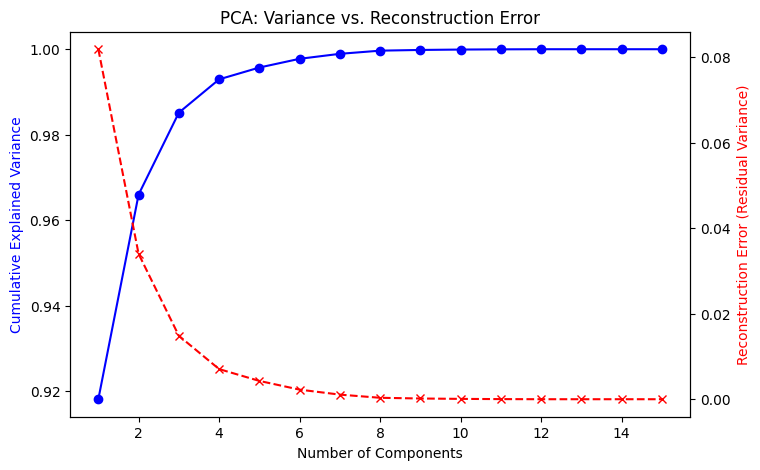

In [10]:
# 1. Calculate the cumulative variance
# check up to, 15 components to see where the curve flattens out
pca_test = PCA(n_components=15)

# FIT THE MODEL TO THE DATA 
pca_test.fit(x_train[la_family_refined].dropna())

# Calculate Cumulative Explained Variance
cum_var = np.cumsum(pca_test.explained_variance_ratio_)

# Residual Variance 
res_var = 1 - cum_var

# Plot
fig, ax1 = plt.subplots(figsize=(8,5))

ax1.plot(range(1, len(cum_var)+1), cum_var, color='blue', marker='o', label='Explained Variance')
ax1.set_xlabel('Number of Components')
ax1.set_ylabel('Cumulative Explained Variance', color='blue')

ax2 = ax1.twinx()
ax2.plot(range(1, len(cum_var)+1), res_var, color='red', marker='x', linestyle='--', label='Reconstruction Error')
ax2.set_ylabel('Reconstruction Error (Residual Variance)', color='red')

plt.title('PCA: Variance vs. Reconstruction Error')
plt.show()

A Scree analysis to compare cumulative explained variance against residual reconstruction error. The intersection of these two curves occurs at 2 components, indicating that 2 dimensions are sufficient to capture the 'elbow' of the information content—effectively balancing dimensionality reduction with the loss of detail

In [11]:
# Initialize PCA 
# Start with a conservative number of components
la_pca = PCA(n_components=2, random_state=42)

# Fit on training data only to avoid data leakage
la_pca.fit(x_train[la_family_refined].dropna())

# Transform both training and test data
x_train_pca = la_pca.transform(x_train[la_family_refined].dropna())
x_test_pca = la_pca.transform(x_test[la_family_refined].dropna())

# Create readable column names for the PCA components
pca_columns = [f'PCA_Component_{i+1}' for i in range(la_pca.n_components_)]

# Convert the PCA results back into DataFrames for easier handling
x_train_pca_df = pd.DataFrame(x_train_pca, columns=pca_columns, index=x_train[la_family_refined].dropna().index)
x_test_pca_df = pd.DataFrame(x_test_pca, columns=pca_columns, index=x_test[la_family_refined].dropna().index)

# Ensure the indices match after dropna
assert x_train_pca_df.index.equals(y_train.loc[x_train_pca_df.index].index)
assert x_test_pca_df.index.equals(y_test.loc[x_test_pca_df.index].index)
print("Indices are perfectly aligned. Ready to concatenate!")

Indices are perfectly aligned. Ready to concatenate!


### 5.3 Unified Pipeline:
Pass these 2–3 new "Access Components" into the model instead of the 78 raw columns

**Index-Preserving Dimensionality Reduction**: PCA will be applied to the la_family_refined block of features, and the resulting components will be added to the dataset as new features. The original la_family_refined columns will be dropped, preserving the index of the dataset for downstream modeling.

In [12]:
# Drop the original la_family columns from x_train and x_test
x_train_final = x_train.drop(columns=la_family_refined)
x_test_final = x_test.drop(columns=la_family_refined)

# Add the new PCA components
x_train_final = pd.concat([x_train_final, x_train_pca_df], axis=1)
x_test_final = pd.concat([x_test_final, x_test_pca_df], axis=1)

# Final check for NaNs (PCA results shouldn't have any, but good to be safe)
x_train_final = x_train_final.dropna()
x_test_final = x_test_final.dropna()

# Update your Y-labels to match the cleaned X-frames
y_train_final = y_train.loc[x_train_final.index]
y_test_final = y_test.loc[x_test_final.index]

# Final sanity check print
print(f"Final training set size: {x_train_final.shape}")
print(f"Final training target size: {y_train_final.shape}")

Final training set size: (1832, 43)
Final training target size: (1832,)


In [13]:
# See which original features contribute most to your first PC
loadings = pd.DataFrame(la_pca.components_.T, columns=pca_columns, index=la_family_refined)
print(loadings.sort_values(by='PCA_Component_1', ascending=False).head(10))

               PCA_Component_1  PCA_Component_2
TractWhite            0.675319        -0.566296
TractHispanic         0.434193         0.697926
TractLOWI             0.412786         0.096845
TractKids             0.287954        -0.037815
TractOMultir          0.218565         0.341204
TractBlack            0.140639        -0.193776
TractSeniors          0.129987        -0.078538
TractAsian            0.117373         0.137433
TractSNAP             0.046110        -0.036497
TractHUNV             0.041152        -0.031683


**PCA_Component_1: The "General Demographic Density Index"**:

*High positive weights* TractWhite (0.67), TractHispanic (0.43), TractLOWI (0.41), TractKids (0.28).

This component acts as a "scale" factor. High values on Component 1 likely represent census tracts with higher overall populations across these major demographic groups. It captures the "base intensity" of the tract’s population

**PCA_Component_2: The "Ethnic Concentration/Composition Index"**:

*High positive weights* TractHispanic (0.70), TractOMultir (0.34).

*High negative weights* TractWhite (-0.56).

This component represents a demographic contrast. High values on Component 2 indicate a shift toward Hispanic and Multiracial populations, while low (negative) values indicate a higher concentration of White populations

## 6. Export and Save

In [14]:
# Path setup
base_path = Path.cwd().parents[1]
processed_dir = base_path / "data" / "final" 

# Ensure the folder exists (best practice)
processed_dir.mkdir(parents=True, exist_ok=True)

In [15]:
# Save your DataFrames to CSV
x_train_final.to_csv(processed_dir / "X_train.csv", index=True)
x_test_final.to_csv(processed_dir / "X_test.csv", index=True)
y_train_final.to_csv(processed_dir / "y_train.csv", index=True)
y_test_final.to_csv(processed_dir / "y_test.csv", index=True)

print(f"Files saved successfully!")

Files saved successfully!


## 7. Findings and Next Steps

| Task | Result | Decision |
|---|---|---|
|Drop Rows with Missing Target Values| 275 rows dropped | Proceed with remaining 2,956 rows |
|Feature Redundancy| USDA and Census income variables highly correlated (0.91) |create a "Consensus Income" variable. Retain all variables in the dataset and decide drop conditions after LASSO and PCA analysis|
|Data Block Analysis| 77 of 78 USDA la*/Tract* columns have VIF above 10, dozens reach 10¹³–10¹⁵ | Drop all "number" columns and retain all "share" columns. Apply PCA to the remaining la* and Tract* features to create 2–3 "Access Components" that capture the variance without multicollinearity. |
|Train /Test Split| 80/20 split | Use CHR&R dataset for K-Fold Cross-Validation. K-Fold CV: Used during training to tune hyperparameters (like the penalty strength in LASSO) without touching the Test set. |
|PCA Scree Analysis| 2 components sufficient to capture the 'elbow' of the information content | Use 2 PCA components in the model instead of raw columns |

**Next steps.** Perform feature selection using LASSO regression to isolate the most predictive variables from the 43 remaining features. Following this, the finalized feature subset will be used to train and evaluate the predictive models for county-level hypertension prevalence.